# Transferring 3D annotations between different reconstructions of the same pointcloud
This tutorial covers how to (1) obtain image matches for 3D points in a pointcloud and how to export these, and (2) how to import these image matches and then back-project these to 3D points in a pointcloud with a different coordinate system but based on the same imagery dataset. This workflow can be useful when transferring 3D anotations to a new version of a pointcloud that has different coordinates.

In short this can be achieved/scripted through the below code - but this tutorial will give a step-by-step explanation with checks.

In [ ]:
from substrata import *

# Load in the original annotations and cameras
annos = Annotations(annotations_filepath)
old_cams = Cameras(old_cams_meta_json_filepath, old_cams_xml_filepath)

# Obtain image matches and save annotations (to include the first image matches)
matches = annos.get_first_image_matches(old_cams)
annos.save(annotations_with_matches_filepath)

# Load in the new pointcloud and camera files
project = ProjectInitializer(new_project_filepath)
project.initialize()

# Reload the annotations with the image matches and project the pixel coordinates to 3D points
annos = Annotations(annotations_with_matches_filepath)

for ann in annos:
    cam = project.cams.get_camera_by_filepath(ann.cam_filepath)
    ann.coords = cam.pixel_to_point(ann.cam_x, ann.cam_y, project.pcd)[0]

# Obtain the original coordinates (based on project.world_transform) and save the annotations
annos.get_original_coords(project.world_transform)
annos.save(new_annotations_filepath)

## Loading in the old annotations and exporting image matches
The first step is to load in the annotations file and cameras files in the old coordinate system. 

In [2]:
from substrata import *

annos = Annotations("/mnt/sdd/tonga_focal/ton_tof/ton_tof_60m/ton_tof_60m_20241008/old_versions/ton_tof_60m_20241008_QC_ann.csv")
old_cams = Cameras("/mnt/sdd/tonga_focal/ton_tof/ton_tof_60m/ton_tof_60m_20241008/old_versions/ton_tof_60m_20241008.meta.json",
               "/mnt/sdd/tonga_focal/ton_tof/ton_tof_60m/ton_tof_60m_20241008/old_versions/ton_tof_60m_20241008.cams.xml")

Although not technically needed, it can be useful to also load the old pointcloud to verify the annotations and cameras are in that coordinate system. Note that in this example we have not scaled/oriented the old pointcloud. 

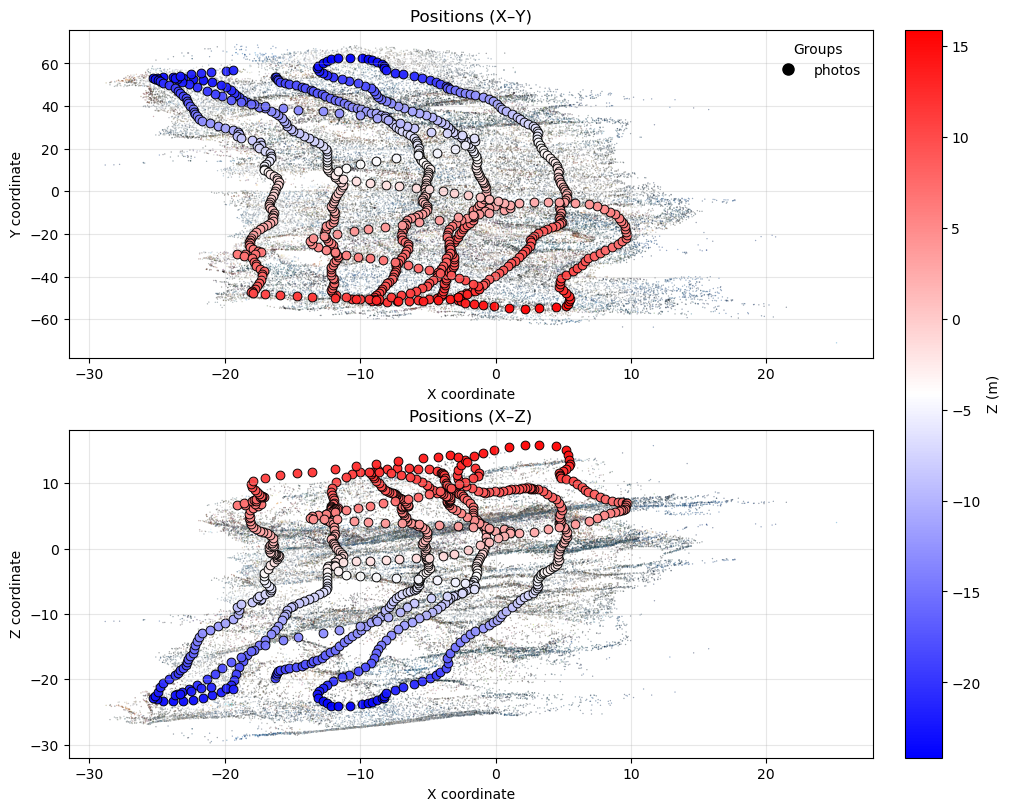

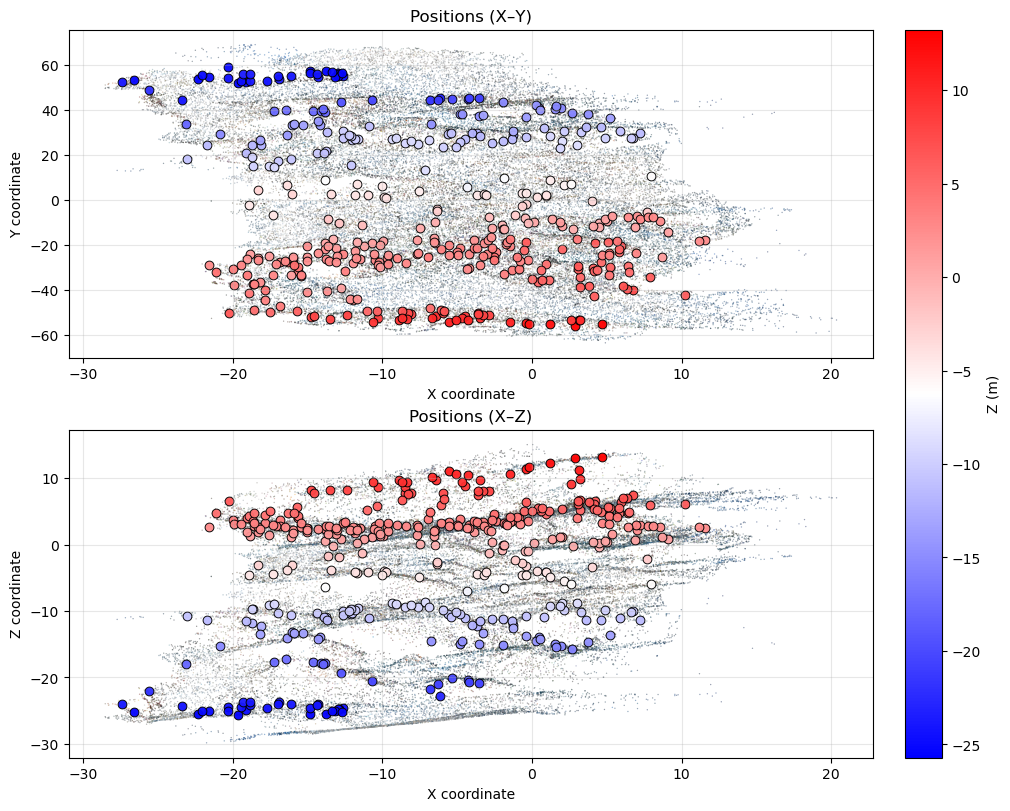

In [3]:
# Load the old pointcloud
old_pcd = PointCloud("/mnt/sdd/tonga_focal/ton_tof/ton_tof_60m/ton_tof_60m_20241008/old_versions/ton_tof_60m_20241008_dec7M.ply")
# Show the old cameras and annotations overlaid on the old pointcloud
old_cams.show(old_pcd, color=True)
annos.show(old_pcd, color=True)

If the paths in the old camera files are correct, we can show image matches for the first several annotations to see if they are correct.

Image match for camera 501 at 8523, 3296
Depth: 2.0120437098255373, Relevance: 0.001895460472660019
No obstruction check performed


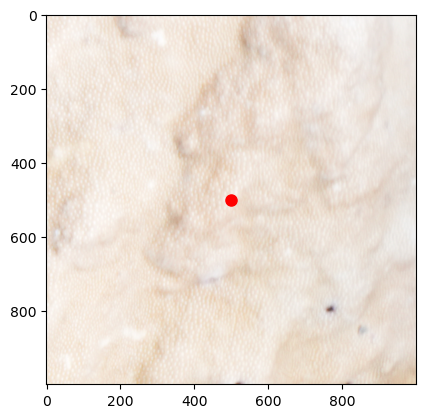

Image match for camera 509 at 8002, 3401
Depth: 3.0190319404588912, Relevance: 0.003083781610158163
No obstruction check performed


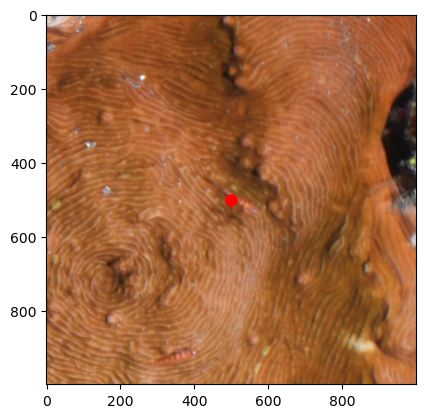

Image match for camera 210 at 2003, 3633
Depth: 3.003499159012833, Relevance: 0.0025619569476796455
No obstruction check performed


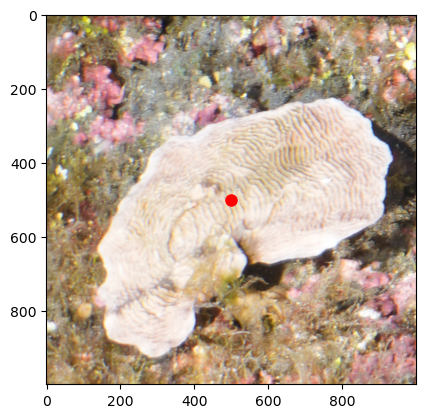

In [4]:
# Optional camera filepath find/replace and filename prefix if cameras have moved / been renamed
old_cams.set_filepath_replace("/home/coral3d/focal_plots/", "/mnt/sdd/tonga_focal/")
old_cams.filename_prefix = "PGRAM01_"

for ann in annos.subset(3):
    img_match = ann.get_first_image_match(old_cams)
    if img_match is not None:
        img_match.show()

Now ensure that image matches are determined for all the annotations and save the annotations back to file (where the first image matches get saved in the `cam_filepath`, `cam_x` and `cam_y` columns).

In [5]:
matches = annos.get_first_image_matches(old_cams)
annos.save("/mnt/sdd/tonga_focal/ton_tof/ton_tof_60m/ton_tof_60m_20241008/old_versions/ton_tof_60m_20241008_QC_ann_with_matches.csv")

Getting first image matches: 100%|██████████| 395/395 [00:02<00:00, 185.67it/s]


## Loading in the new pointcloud and camera files and importing the old annotations based on 2D image coordinates
Start with loading the new files - here we use the `ProjectInitializer` to also straight away load the accompanying transformation transforms, but you can also load the pointcloud and camera files individually as above.

In [6]:
project = ProjectInitializer('/mnt/sdd/tonga_focal/ton_tof/ton_tof_60m/ton_tof_60m_20241008/ton_tof_60m_20241008.yaml')
project.initialize()

Loading project from YAML file: /mnt/sdd/tonga_focal/ton_tof/ton_tof_60m/ton_tof_60m_20241008/ton_tof_60m_20241008.yaml
Loading pointcloud from /mnt/sdd/tonga_focal/ton_tof/ton_tof_60m/ton_tof_60m_20241008/ton_tof_60m_20241008_dec50M.ply
Loading cameras from /mnt/sdd/tonga_focal/ton_tof/ton_tof_60m/ton_tof_60m_20241008/ton_tof_60m_20241008.meta.json and /mnt/sdd/tonga_focal/ton_tof/ton_tof_60m/ton_tof_60m_20241008/ton_tof_60m_20241008.cams.xml
Loading markers from /mnt/sdd/tonga_focal/ton_tof/ton_tof_60m/ton_tof_60m_20241008/ton_tof_60m_20241008_markers.csv
Applying world_transform to loaded objects:
[[-1.80410230e-02 -2.91692826e-01  1.99137504e-02  1.65941540e+01]
 [ 2.84423442e-01 -2.21303402e-02 -6.64852979e-02  6.60038486e+00]
 [ 6.77094401e-02  1.52408664e-02  2.84587225e-01 -5.88746699e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


Load in the old annotations (that now contain the image matches as separate columns):

In [7]:
annos = Annotations("/mnt/sdd/tonga_focal/ton_tof/ton_tof_60m/ton_tof_60m_20241008/old_versions/ton_tof_60m_20241008_QC_ann_with_matches.csv")

For each annotation find the correct camera match (based on filepath as the cam id may have changed between projects), and then project the image pixel coordinates to obtain a 3D point (for this it will be helpful to work with a scaled pointcloud in order to correc back-projection error)

In [8]:
for ann in annos:
    cam = project.cams.get_camera_by_filepath(ann.cam_filepath)
    ann.coords = cam.pixel_to_point(ann.cam_x, ann.cam_y, project.pcd)[0]

However, because the new pointcloud is scaled(/oriented) - we need to recalculate the `orig_coords` using the world_transform of the project:

In [9]:
annos.get_original_coords(project.world_transform)

We can now double-check these project match up, and how much they deviate in pixel distance when back-projected (from 3D to 2D image pixel coords)

Image match for camera 511 at 8517, 3298
Depth: 1.4770409925052173, Relevance: 0.0011055488032527007
No obstruction check performed


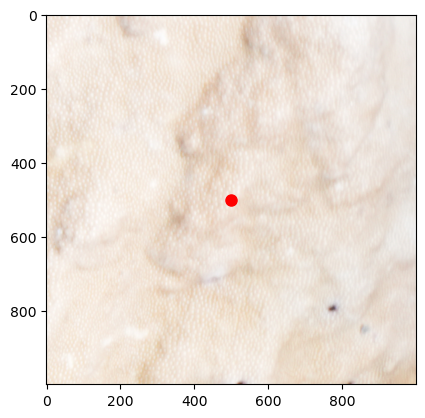

Image match for camera 519 at 8004, 3402
Depth: 2.308539993543235, Relevance: 0.0019175054132211577
No obstruction check performed


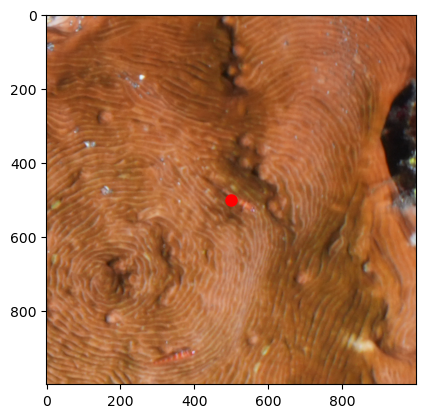

Image match for camera 220 at 2006, 3635
Depth: 2.192156688571502, Relevance: 0.001470067839997776
No obstruction check performed


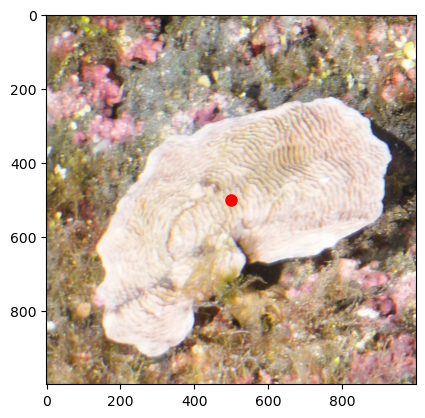

In [10]:
for ann in annos.subset(3):
    img_match = ann.get_first_image_match(project.cams)
    if img_match is not None:
        img_match.show()

The last step is to save this annotation file under a different name:

In [11]:
annos.save("/mnt/sdd/tonga_focal/ton_tof/ton_tof_60m/ton_tof_60m_20241008/ton_tof_60m_20241008_QC_ann.csv")